In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y
import pandas as pd
from planetmagfields import Planet
from inversemodel import InverseModel

# Make figures svg
%config InlineBackend.figure_formats = ['svg']
savefigs = False

## Read data

In [3]:
df = pd.read_csv('./pds_data/uranus48s.csv')

theta = df['Colatitude'] * np.pi / 180
phi = (df['Longitude'] % 360) * np.pi / 180
r = df['Radius'].values

## Inverse Modeling

## Find optimal $\alpha$

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:23<00:00,  4.18it/s]


Optimal α (L-curve): 6.58e-07


100%|██████████| 100/100 [00:16<00:00,  6.23it/s]


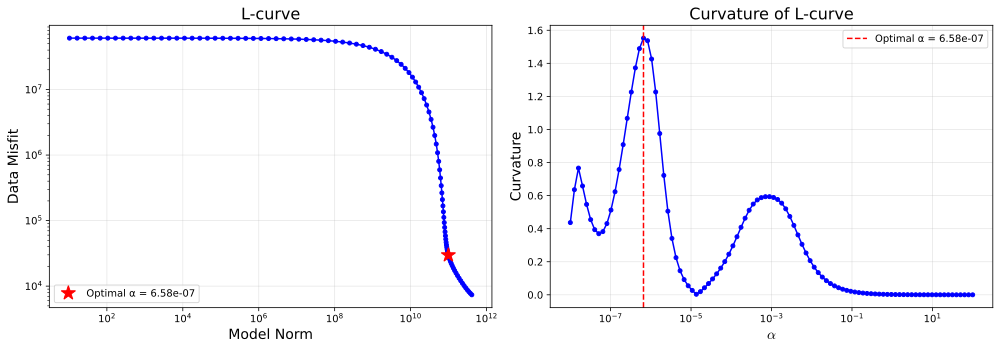

In [4]:
# Create model
M = InverseModel(lmax=3, r=r, theta=theta, phi=phi,
                 br=df['Br'].values,
                 btheta=df['Btheta'].values,
                 bphi=df['Bphi'].values,
                 smoothing_norm='ohmic',
                 include_external=True,
                 a=1,b=0.8,c=0.7)

# Define alpha range
alpha_arr = np.logspace(-8, 2, 100)

# Method 1: L-curve
alpha_opt_lcurve, idx_opt, curvature = M.find_optimal_alpha(alpha_arr)
print(f"Optimal α (L-curve): {alpha_opt_lcurve:.2e}")

# Plot
M.plot_trade_off_curve(alpha_arr)

# Solve with optimal alpha
M.solve(alpha=alpha_opt_lcurve)

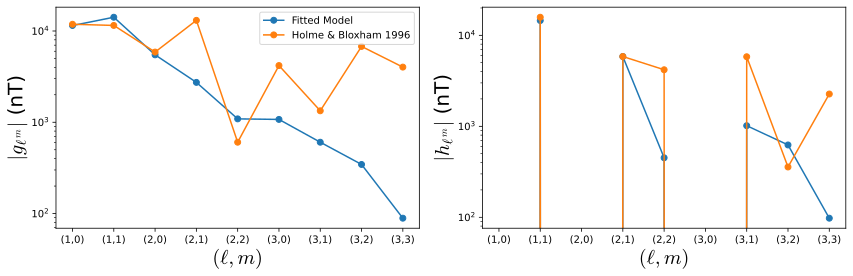

In [5]:
pl = Planet(name='Uranus', model='holme1996', info=False, units='nT')
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,4))
for i in [0,1]:
    if i == 0:
        coeff = M.glm[:9]
        coeff_ref = pl.glm[1:10]
        ylabel = r'$|g_{\ell^m}|$ (nT)'
    if i == 1:
        coeff = M.hlm[:9]
        coeff_ref = pl.hlm[1:10]
        ylabel = r'$|h_{\ell^m}|$ (nT)'

    ax[i].plot(np.abs(coeff),'-o',label='Fitted Model')
    ax[i].plot(np.abs(coeff_ref),'-o',label='Holme & Bloxham 1996')
    ax[i].set_yscale('log')
    ax[i].set_xlabel(r'$(\ell,m)$',fontsize=20)
    ax[i].set_xticks(np.arange(9))
    ax[i].set_xticklabels(['(1,0)','(1,1)','(2,0)','(2,1)','(2,2)','(3,0)','(3,1)','(3,2)','(3,3)'])
    ax[i].tick_params(axis='both', which='major', labelsize=10)
    ax[i].set_ylabel(ylabel,fontsize=20)

ax[0].legend()
fig.tight_layout()
# plt.savefig('./plots/uranus_fitted_gauss_coefficients.png',dpi=300)
plt.show()

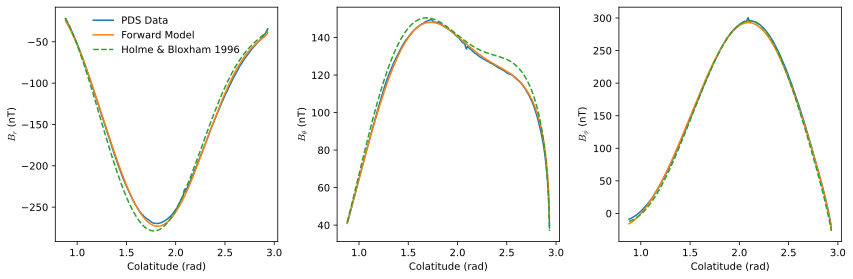

In [6]:
#Test both forward models:

b = np.real(M.A @ M.coeffs)
br = b[0::3]
btheta = b[1::3]
bphi = b[2::3]

# Rearrange Holme and Bloxham 1996 coefficients into same format as M.coeffs
pl = Planet(name='Uranus', model='holme1996', info=False, units='nT')
coeffs_hb = np.zeros(M.ncoeffs)

for l in range(1, min(M.lmax,pl.lmax) + 1):
    for m in range(l + 1):
        # Get coefficient from pl using pl's indexing
        coeffs_hb[M.idx_g[l, m]] = pl.glm[pl.idx[l, m]]

        if m > 0:
            coeffs_hb[M.idx_h[l, m]] = pl.hlm[pl.idx[l, m]]

# Forward model
b_hb = M.A @ coeffs_hb
br_hb = b_hb[0::3]
btheta_hb = b_hb[1::3]
bphi_hb = b_hb[2::3]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4), sharex=True)
ax[0].plot(theta, df['Br'], label='PDS Data')
ax[0].plot(theta, br, label='Forward Model')
ax[0].plot(theta, br_hb, label='Holme & Bloxham 1996', linestyle='--')
ax[0].set_ylabel(r'$B_r$ (nT)')
ax[0].set_xlabel('Colatitude (rad)')
ax[0].legend(frameon=False)
ax[1].plot(theta, df['Btheta'])
ax[1].plot(theta, btheta)
ax[1].plot(theta, btheta_hb, linestyle='--')
ax[1].set_ylabel(r'$B_\theta$ (nT)')
ax[1].set_xlabel('Colatitude (rad)')
ax[2].plot(theta, df['Bphi'])
ax[2].plot(theta, bphi)
ax[2].plot(theta, bphi_hb, linestyle='--')
ax[2].set_ylabel(r'$B_\phi$ (nT)')
ax[2].set_xlabel('Colatitude (rad)')
fig.tight_layout()
# plt.savefig('./plots/uranus_forward_model.png', dpi=300)
plt.show()

In [7]:
# Print external coefficients:

print(f"External field coefficients:")
print(f"  G10 = {M.G10:.2f} nT")
print(f"  G11 = {M.G11:.2f} nT")
print(f"  H11 = {M.H11:.2f} nT")

External field coefficients:
  G10 = -2.91 nT
  G11 = -3.62 nT
  H11 = -10.24 nT


In [8]:
# Compare actual values
print("Model glm:", M.glm)
print("Holme & Bloxham glm:", pl.glm[1:])
print("Model hlm:", M.hlm)
print("Holme & Bloxham hlm:", pl.hlm[1:])

Model glm: [11496.3832594  14152.7018501  -5481.69376475 -2735.66503447
  1089.51515984  1074.5485464   -604.55210139  -345.00136321
    88.94992339]
Holme & Bloxham glm: [ 11854.69  11507.23  -5877.08 -13084.9    -604.66   4182.82  -1335.73
  -6776.28  -4021.38]
Model hlm: [     0.         -14540.84960035      0.           5853.09703115
   -450.99304655      0.          -1015.84774831   -624.00605961
     97.78345442]
Holme & Bloxham hlm: [     0.    -15811.9        0.      5850.66    4184.69       0.
  -5816.665   -357.27   -2265.15 ]
